# Quelles pannes sont réellement détectées — NIST 14 & 16 SEER

Le leave-one-machine-out publie **accuracy 0,602** et **F1 macro 0,479**. Douze points
d'écart : les six classes ne sont pas détectées également. Une moyenne ne dit rien à un
praticien. Cette note nomme les pannes.

Chargement, étiquetage (tolérance 2 %), conversions SI, huit résidus, kNN sain et
`GradientBoostingClassifier(random_state=42)` : **identiques** à
`EDA_NIST_model.ipynb` / `EDA_NIST_calibration.ipynb`. On décrit, on n'optimise pas.

### Les quatre questions

1. Quelles classes sont détectées, lesquelles ne le sont pas ?
2. Avec quoi se confondent-elles ?
3. Les deux sens du leave-one-machine-out sont-ils d'accord ?
4. La calibration profite-t-elle à toutes les classes ?

### Protocole

Leave-one-machine-out, les deux sens. Features = les 8 résidus seuls. Référence saine :
médiane des 5 plus proches en `(T_source, T_sink)`.

| Origine de la référence | Accuracy | F1 macro |
|---|---|---|
| Machine cible (calibrée, `n = all`) | 0,602 | 0,479 |
| Machine d'entraînement (transférée, `n = 0`) | 0,318 | 0,290 |

`n = all` laisse les sains dans le test — c'est le protocole publié. `n = 0` n'en a
aucun à retirer. Pression d'aspiration : `1701_ODVapSV_psia`, jamais `1710`.
`EF` / `CF` / `LL` / `UC/OC` / `NF` ne sont jamais des features.

> **Données non versionnées.** Placer `fdd_1416seer.xlsx` dans `data/nist/`.


## 0 — Jeu, comme les notebooks précédents


In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, precision_recall_fscore_support, confusion_matrix,
)

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'requirements.txt').exists())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
NIST = ROOT / 'data' / 'nist'
assert (NIST / 'fdd_1416seer.xlsx').exists(), 'Placer les xlsx NIST dans data/nist/ (non versionnés).'

BLUE, ORANGE, AQUA = '#2a78d6', '#eb6834', '#1baf7a'
INK, MUTED, GRID = '#0b0b0b', '#52514e', '#e4e3df'
plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': 'white', 'axes.edgecolor': GRID,
    'axes.labelcolor': MUTED, 'text.color': INK, 'xtick.color': MUTED, 'ytick.color': MUTED,
    'axes.grid': True, 'grid.color': GRID, 'grid.linewidth': 0.8, 'axes.axisbelow': True,
    'axes.spines.top': False, 'axes.spines.right': False, 'font.size': 10,
})

F2C = lambda s: (s - 32) * 5 / 9
dF2K = lambda s: s * 5 / 9
PSI2BAR, BTU2W = 0.0689476, 0.293071

df = pd.read_excel(NIST / 'fdd_1416seer.xlsx')

FAULTCOLS = {'EF': 'Evap_Airflow', 'CF': 'Cond_Blockage', 'LL': 'LiquidLine', 'UC/OC': 'Charge'}

def fault_label(row, tol=2.0):
    active = []
    for col, name in FAULTCOLS.items():
        v = row[col]
        if pd.isna(v) or abs(v - 100) <= tol:
            continue
        if name == 'Charge':
            name = 'Undercharge' if v < 100 else 'Overcharge'
        active.append(name)
    if not active:
        return 'No_Fault'
    return active[0] if len(active) == 1 else 'MULTI:' + '+'.join(sorted(active))

df['fault_class'] = df.apply(fault_label, axis=1)

m16 = df.Rated_SEER == 16.0
assert (df.loc[m16, '1710_ODSuctPort_psia'] == df.loc[m16, 'CompDisch_psia']).all()

X = pd.DataFrame(index=df.index)
X['P_evap'] = df['1701_ODVapSV_psia'] * PSI2BAR      # ← pas 1710
X['P_cond'] = df['CompDisch_psia'] * PSI2BAR
X['pressure_ratio'] = X.P_cond / X.P_evap
X['T_suction'] = F2C(df['1608_CompSuct_TempF'])
X['T_discharge'] = F2C(df['1617_CompDisch_TempF'])
X['T_evap'] = F2C(df['CompSuct_Tsat_F'])
X['T_cond'] = F2C(df['CompDisch_Tsat_F'])
X['superheat'] = dF2K(df['CompSuct_Suph_F'])
X['subcooling'] = dF2K(df['ODLiqSV_Tsub_F'])
X['Q_evap'] = df['TOTAL Capacity (Btu/h)'] * BTU2W
X['W_od'] = df['OD_Xitron_Watts']
X['COP'] = df['COP']
X['T_source'] = F2C(df['Inlet TC Grid AVG Temp (F)'])
X['T_sink'] = F2C(df['OD Air AVG DB (F)'])
X['delta_T_evap'] = X.T_source - X.T_evap
X['delta_T_cond'] = X.T_cond - X.T_sink

LEAK = ['EF', 'CF', 'LL', 'UC/OC', 'NF']
assert not any(c in X.columns for c in LEAK)

y, grp = df.fault_class, df.Rated_SEER
keep = grp.isin([14.0, 16.0]) & (~y.str.startswith('MULTI')) & X.notna().all(axis=1)
X, y, grp = X.loc[keep].copy(), y.loc[keep].copy(), grp.loc[keep].copy()

RES = ['superheat', 'subcooling', 'T_discharge', 'COP', 'W_od', 'P_evap', 'P_cond', 'pressure_ratio']
COND = ['T_source', 'T_sink']
DCOLS = ['d_' + c for c in RES]
LABELS = ['No_Fault', 'Undercharge', 'Overcharge', 'Evap_Airflow', 'LiquidLine', 'Cond_Blockage']
FR = {
    'No_Fault': 'sans défaut',
    'Undercharge': 'sous-charge',
    'Overcharge': 'surcharge',
    'Evap_Airflow': 'débit intérieur',
    'LiquidLine': 'ligne liquide',
    'Cond_Blockage': 'obstruction condenseur',
}

print(f'{len(X)} lignes · {y.nunique()} classes')
print(dict(y.value_counts()))
print('sains par machine :', dict(y[y == 'No_Fault'].groupby(grp).size()))


5386 lignes · 6 classes
{'No_Fault': np.int64(1352), 'Undercharge': np.int64(1228), 'Overcharge': np.int64(942), 'Evap_Airflow': np.int64(774), 'LiquidLine': np.int64(593), 'Cond_Blockage': np.int64(497)}
sains par machine : {14.0: np.int64(727), 16.0: np.int64(625)}
sains par machine : {14.0: np.int64(727), 16.0: np.int64(625)}


## 1 — Un classifieur par pli, deux origines de référence

Les résidus d'entraînement ne dépendent pas de la calibration : kNN sur les sains de la
machine d'entraînement. Le classifieur est ajusté **une fois par pli**. Seule la référence
du test change.


In [2]:
def knn_predict(Xh_cond, Xh_res, X_cond, k=5):
    k = min(int(k), len(Xh_cond))
    tree = cKDTree(np.asarray(Xh_cond, dtype=float))
    _, idx = tree.query(np.asarray(X_cond, dtype=float), k=k)
    if idx.ndim == 1:
        idx = idx[:, None]
    return np.median(np.asarray(Xh_res)[idx], axis=1)


folds = {}
for test_seer in (14.0, 16.0):
    tr = (grp != test_seer)
    te = (grp == test_seer)
    h_tr = tr & (y == 'No_Fault')
    pred_tr = knn_predict(X.loc[h_tr, COND], X.loc[h_tr, RES], X.loc[tr, COND], k=5)
    Dtr = pd.DataFrame(X.loc[tr, RES].to_numpy() - pred_tr, index=X.index[tr], columns=DCOLS)
    clf = GradientBoostingClassifier(random_state=42).fit(Dtr, y.loc[tr])
    folds[test_seer] = {
        'tr': tr, 'te': te, 'h_tr': h_tr, 'clf': clf,
        'h_te_idx': X.index[te & (y == 'No_Fault')].to_numpy(),
    }
    print(
        f'test {int(test_seer)} SEER · sains train={int(h_tr.sum())} · '
        f'sains test={len(folds[test_seer]["h_te_idx"])} · n_test={int(te.sum())}'
    )


test 14 SEER · sains train=625 · sains test=727 · n_test=2420
test 16 SEER · sains train=727 · sains test=625 · n_test=2966


In [3]:
def run(mode):
    """mode: 'calibrated' (n=all, sains cible) ou 'transferred' (n=0, sains train)."""
    out = []
    for test_seer in (14.0, 16.0):
        f = folds[test_seer]
        te, h_tr, h_te_idx, clf = f['te'], f['h_tr'], f['h_te_idx'], f['clf']
        src_idx = h_te_idx if mode == 'calibrated' else X.index[h_tr]
        pred_te = knn_predict(X.loc[src_idx, COND], X.loc[src_idx, RES], X.loc[te, COND], k=5)
        Dte = pd.DataFrame(X.loc[te, RES].to_numpy() - pred_te, index=X.index[te], columns=DCOLS)
        hat = clf.predict(Dte)
        yte = y.loc[X.index[te]]
        p, r, f1, s = precision_recall_fscore_support(yte, hat, labels=LABELS, zero_division=0)
        out.append({
            'test': int(test_seer),
            'acc': accuracy_score(yte, hat),
            'f1_macro': f1_score(yte, hat, average='macro'),
            'yte': yte, 'hat': hat,
            'precision': p, 'recall': r, 'f1': f1, 'support': s,
            'cm': confusion_matrix(yte, hat, labels=LABELS),
        })
    return out


def table(rows, title):
    recs = []
    for row in rows:
        for i, lab in enumerate(LABELS):
            recs.append({
                'sens': f"→ {row['test']} SEER",
                'classe': FR[lab],
                'précision': row['precision'][i],
                'rappel': row['recall'][i],
                'F1': row['f1'][i],
                'n': int(row['support'][i]),
            })
    t = pd.DataFrame(recs)
    mean_acc = float(np.mean([r['acc'] for r in rows]))
    mean_f1 = float(np.mean([r['f1_macro'] for r in rows]))
    print(title)
    print(f'  moyenne des deux plis : acc={mean_acc:.3f}  F1 macro={mean_f1:.3f}')
    for r in rows:
        print(f"  → {r['test']} SEER : acc={r['acc']:.3f}  F1 macro={r['f1_macro']:.3f}  n={len(r['yte'])}")
    return t, mean_acc, mean_f1


cal = run('calibrated')
trf = run('transferred')
t_cal, acc_cal, f1_cal = table(cal, 'référence calibrée (n = all)')
print()
t_trf, acc_trf, f1_trf = table(trf, 'référence transférée (n = 0)')


référence calibrée (n = all)
  moyenne des deux plis : acc=0.602  F1 macro=0.479
  → 14 SEER : acc=0.637  F1 macro=0.477  n=2420
  → 16 SEER : acc=0.568  F1 macro=0.481  n=2966

référence transférée (n = 0)
  moyenne des deux plis : acc=0.318  F1 macro=0.290
  → 14 SEER : acc=0.209  F1 macro=0.251  n=2420
  → 16 SEER : acc=0.427  F1 macro=0.329  n=2966


### Contrôle de non-régression

La moyenne **non pondérée des deux plis** est le protocole publié (les machines n'ont pas
le même effectif : 2420 vs 2966). Si elle ne retombe pas sur 0,602 / 0,479 et 0,318 / 0,290,
le protocole a divergé — on s'arrête.


In [4]:
ACC_CAL, F1_CAL = 0.602, 0.479
ACC_TRF, F1_TRF = 0.318, 0.290
ok = (
    abs(acc_cal - ACC_CAL) < 0.005 and abs(f1_cal - F1_CAL) < 0.005
    and abs(acc_trf - ACC_TRF) < 0.005 and abs(f1_trf - F1_TRF) < 0.005
)
print(f'calibrée   {acc_cal:.3f} / {f1_cal:.3f}   cible {ACC_CAL:.3f} / {F1_CAL:.3f}')
print(f'transférée {acc_trf:.3f} / {f1_trf:.3f}   cible {ACC_TRF:.3f} / {F1_TRF:.3f}')
if not ok:
    raise RuntimeError('bornes non retrouvées — protocole mal implémenté, on s\'arrête.')
print('bornes OK.')

# L'accuracy d'un pli EST la moyenne du rappel pondérée par l'effectif.
for name, rows in [('calibrée', cal), ('transférée', trf)]:
    for r in rows:
        w = r['support'] / r['support'].sum()
        rec_w = float(np.dot(r['recall'], w))
        assert abs(rec_w - r['acc']) < 1e-12
print('rappel pondéré par n = accuracy, pli par pli.')


calibrée   0.602 / 0.479   cible 0.602 / 0.479
transférée 0.318 / 0.290   cible 0.318 / 0.290
bornes OK.
rappel pondéré par n = accuracy, pli par pli.
rappel pondéré par n = accuracy, pli par pli.


## 2 — Précision, rappel, F1, effectif

Les deux machines n'ont pas la même mixité : 856 sous-charges sur la 14 SEER contre 372 sur
la 16 ; 114 surcharges contre 828. Un F1 sur 114 essais n'est pas un F1 sur 828.


In [5]:
def mean_by_class(rows):
    recs = []
    for i, lab in enumerate(LABELS):
        recs.append({
            'classe': FR[lab],
            'précision': float(np.mean([r['precision'][i] for r in rows])),
            'rappel': float(np.mean([r['recall'][i] for r in rows])),
            'F1': float(np.mean([r['f1'][i] for r in rows])),
            'n total': int(sum(r['support'][i] for r in rows)),
        })
    return pd.DataFrame(recs).set_index('classe').round(3)

print('référence calibrée — moyenne des deux sens')
mean_by_class(cal)


référence calibrée — moyenne des deux sens


,précision,rappel,F1,n total
classe,,,,
sans défaut,0.722,0.837,0.741,1352
sous-charge,0.748,0.961,0.832,1228
surcharge,0.735,0.775,0.674,942
débit intérieur,0.269,0.313,0.288,774
ligne liquide,0.206,0.068,0.040,593
obstruction condenseur,0.611,0.220,0.299,497


In [6]:
print('référence calibrée — les deux sens, non fusionnés')
t_cal.assign(**{c: t_cal[c].round(3) for c in ['précision', 'rappel', 'F1']})


référence calibrée — les deux sens, non fusionnés


,sens,classe,précision,rappel,F1,n
0,→ 14 SEER,sans défaut,0.898,0.688,0.779,727
1,→ 14 SEER,sous-charge,0.884,0.933,0.908,856
2,→ 14 SEER,surcharge,0.469,1.000,0.639,114
3,→ 14 SEER,débit intérieur,0.248,0.241,0.245,278
4,→ 14 SEER,ligne liquide,0.031,0.119,0.050,101
5,→ 14 SEER,obstruction condenseur,0.781,0.145,0.245,344
6,→ 16 SEER,sans défaut,0.547,0.986,0.703,625
7,→ 16 SEER,sous-charge,0.612,0.989,0.756,372
8,→ 16 SEER,surcharge,1.000,0.551,0.710,828
9,→ 16 SEER,débit intérieur,0.290,0.385,0.331,496


In [7]:
print('référence transférée — moyenne des deux sens')
mean_by_class(trf)


référence transférée — moyenne des deux sens


,précision,rappel,F1,n total
classe,,,,
sans défaut,0.597,0.132,0.131,1352
sous-charge,0.594,0.446,0.481,1228
surcharge,0.800,0.839,0.786,942
débit intérieur,0.253,0.382,0.269,774
ligne liquide,0.004,0.025,0.007,593
obstruction condenseur,0.044,0.138,0.067,497


In [8]:
print('référence transférée — les deux sens, non fusionnés')
t_trf.assign(**{c: t_trf[c].round(3) for c in ['précision', 'rappel', 'F1']})


référence transférée — les deux sens, non fusionnés


,sens,classe,précision,rappel,F1,n
0,→ 14 SEER,sans défaut,1.000,0.023,0.046,727
1,→ 14 SEER,sous-charge,0.665,0.287,0.401,856
2,→ 14 SEER,surcharge,0.630,1.000,0.773,114
3,→ 14 SEER,débit intérieur,0.221,0.104,0.142,278
4,→ 14 SEER,ligne liquide,0.008,0.050,0.013,101
5,→ 14 SEER,obstruction condenseur,0.088,0.276,0.133,344
6,→ 16 SEER,sans défaut,0.195,0.242,0.216,625
7,→ 16 SEER,sous-charge,0.523,0.605,0.561,372
8,→ 16 SEER,surcharge,0.971,0.679,0.799,828
9,→ 16 SEER,débit intérieur,0.284,0.659,0.397,496


## 3 — Matrices de confusion, un sens à la fois

Les matrices ne sont **pas** additionnées : les effectifs diffèrent, et c'est précisément
l'asymétrie que la question 3 cherche.


figure → docs/nist_perclass_confusion.png
figure → docs/nist_perclass_confusion.png


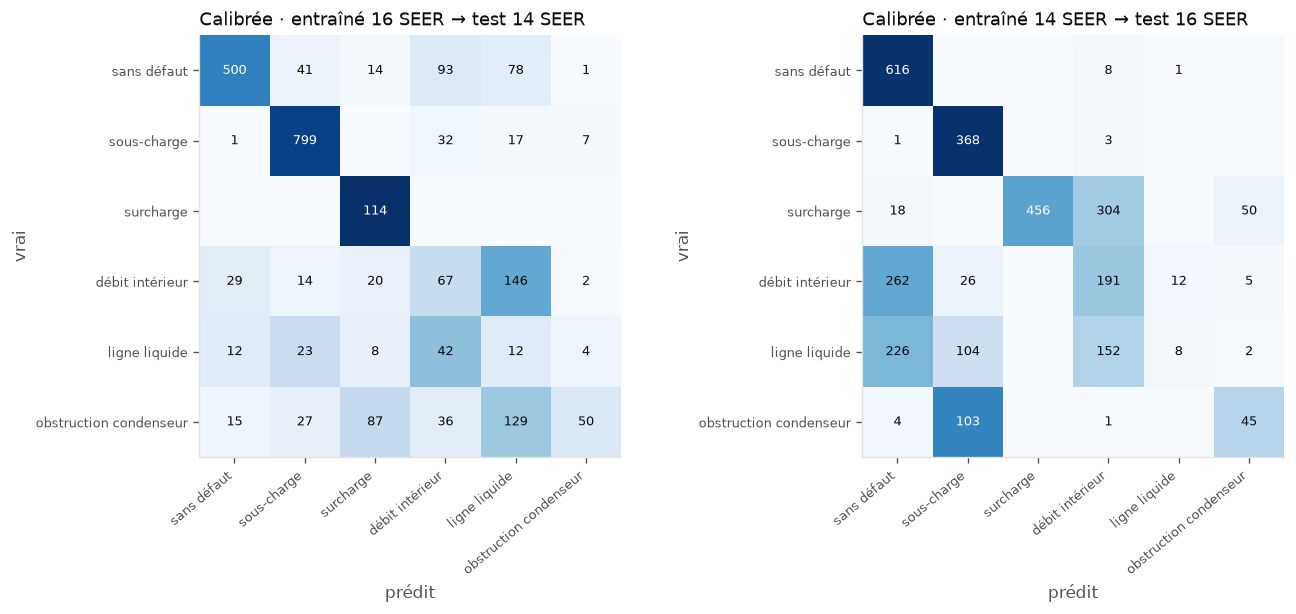

In [9]:
def plot_cm(ax, cm, title):
    cmn = cm / np.maximum(cm.sum(axis=1, keepdims=True), 1)
    im = ax.imshow(cmn, cmap='Blues', vmin=0, vmax=1)
    names = [FR[l] for l in LABELS]
    ax.set_xticks(range(6)); ax.set_yticks(range(6))
    ax.set_xticklabels(names, rotation=40, ha='right', fontsize=8)
    ax.set_yticklabels(names, fontsize=8)
    ax.set_xlabel('prédit'); ax.set_ylabel('vrai')
    ax.set_title(title, loc='left', color=INK, fontsize=11)
    ax.grid(False)
    for i in range(6):
        for j in range(6):
            val = cm[i, j]
            if val == 0:
                continue
            ax.text(j, i, str(val), ha='center', va='center', fontsize=8,
                    color='white' if cmn[i, j] > 0.55 else INK)
    return im

fig, axes = plt.subplots(1, 2, figsize=(11.2, 5.2))
plot_cm(axes[0], cal[0]['cm'], 'Calibrée · entraîné 16 SEER → test 14 SEER')
plot_cm(axes[1], cal[1]['cm'], 'Calibrée · entraîné 14 SEER → test 16 SEER')
fig.tight_layout()
fig_path = ROOT / 'docs' / 'nist_perclass_confusion.png'
fig.savefig(fig_path, dpi=140, bbox_inches='tight')
print('figure →', fig_path.relative_to(ROOT))


## 4 — La calibration profite-t-elle à toutes les classes ?

Même classifieur, mêmes plis. Seule l'origine des sains de référence change.
Le ΔF1 ci-dessous est la moyenne des deux sens.


In [10]:
delta = []
for i, lab in enumerate(LABELS):
    f_cal = float(np.mean([r['f1'][i] for r in cal]))
    f_trf = float(np.mean([r['f1'][i] for r in trf]))
    r_cal = float(np.mean([r['recall'][i] for r in cal]))
    r_trf = float(np.mean([r['recall'][i] for r in trf]))
    delta.append({
        'classe': FR[lab],
        'F1 transférée': f_trf,
        'F1 calibrée': f_cal,
        'ΔF1': f_cal - f_trf,
        'rappel transféré': r_trf,
        'rappel calibré': r_cal,
    })
delta = pd.DataFrame(delta).set_index('classe').round(3)
delta


,F1 transférée,F1 calibrée,ΔF1,rappel transféré,rappel calibré
classe,,,,,
sans défaut,0.131,0.741,0.610,0.132,0.837
sous-charge,0.481,0.832,0.351,0.446,0.961
surcharge,0.786,0.674,-0.111,0.839,0.775
débit intérieur,0.269,0.288,0.018,0.382,0.313
ligne liquide,0.007,0.040,0.034,0.025,0.068
obstruction condenseur,0.067,0.299,0.232,0.138,0.220


figure → docs/nist_perclass_calibration.png
figure → docs/nist_perclass_calibration.png


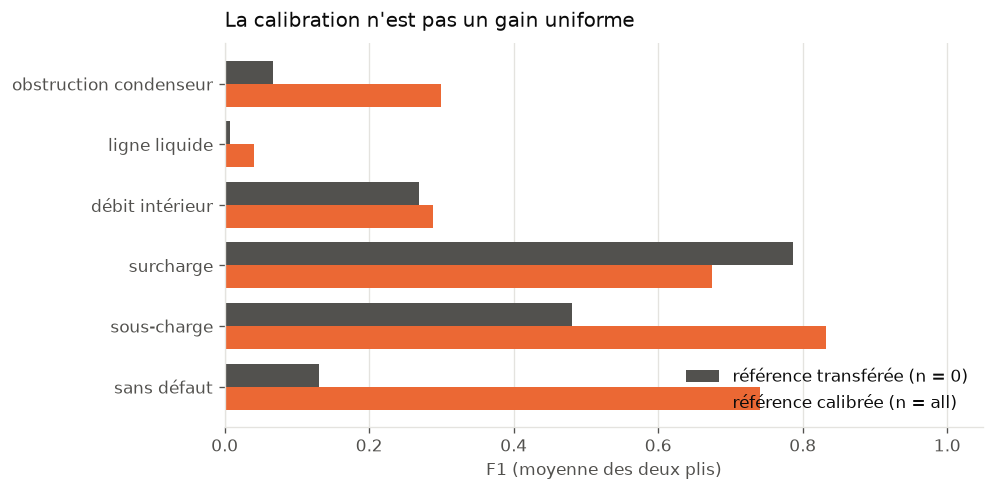

In [11]:
fig, ax = plt.subplots(figsize=(8.4, 4.2))
ypos = np.arange(len(LABELS))
w = 0.38
f_trf = [float(np.mean([r['f1'][i] for r in trf])) for i in range(6)]
f_cal = [float(np.mean([r['f1'][i] for r in cal])) for i in range(6)]
ax.barh(ypos + w/2, f_trf, height=w, color=MUTED, label='référence transférée (n = 0)')
ax.barh(ypos - w/2, f_cal, height=w, color=ORANGE, label='référence calibrée (n = all)')
ax.set_yticks(ypos)
ax.set_yticklabels([FR[l] for l in LABELS])
ax.set_xlim(0, 1.05)
ax.set_xlabel('F1 (moyenne des deux plis)')
ax.set_title('La calibration n\'est pas un gain uniforme', loc='left', color=INK, pad=10)
ax.legend(frameon=False, loc='lower right')
ax.grid(axis='y', visible=False)
fig.tight_layout()
fig_path = ROOT / 'docs' / 'nist_perclass_calibration.png'
fig.savefig(fig_path, dpi=140, bbox_inches='tight')
print('figure →', fig_path.relative_to(ROOT))


## Effectifs par machine

Les mixités ne sont pas les mêmes. C'est pour ça que les matrices ne se somment pas.


In [12]:
print('Effectifs par machine (vrai label)')
print(pd.crosstab(y, grp.rename('SEER')))


Effectifs par machine (vrai label)
SEER           14.0  16.0
fault_class              
Cond_Blockage   344   153
Evap_Airflow    278   496
LiquidLine      101   492
No_Fault        727   625
Overcharge      114   828
Undercharge     856   372
SEER           14.0  16.0
fault_class              
Cond_Blockage   344   153
Evap_Airflow    278   496
LiquidLine      101   492
No_Fault        727   625
Overcharge      114   828
Undercharge     856   372


## Ce que ça dit, panne par panne

Les moyennes 0,602 / 0,479 cachent six histoires. Une par panne, référence calibrée
sauf mention contraire.

**Sous-charge — la seule panne vraiment détectée.** F1 0,83 en moyenne (0,91 sur la 14 SEER,
0,76 sur la 16). Précision et rappel élevés dans les deux sens. Même sans calibration elle
reste la moins mauvaise des pannes « difficiles » (F1 0,48). Un technicien peut s'y fier.

**Surcharge — détectée sans calibration, et la calibration ne l'aide pas.** F1 transférée
0,79 contre 0,67 une fois calibrée. C'est la seule classe dont le F1 **baisse**. La signature
(sous-refroidissement qui monte, travail compresseur qui monte) survit au transfert
d'une machine à l'autre. Le budget de calibration ne la concerne pas.

**Sans défaut — invisible tant qu'on n'a pas calibré.** F1 0,13 transféré, 0,74 calibré
(ΔF1 +0,61, le plus gros gain). Presque tout le saut 0,318 → 0,602 est « apprendre à
reconnaître une machine saine ». Sans essais sains de la cible, le modèle ne sait pas ce
qu'est le nominal.

**Débit intérieur — mal détecté, et la calibration n'y change rien** (F1 0,27 → 0,29).
Sur la 16 SEER, 262 des 496 essais partent en « sans défaut ». Sur la 14, 146 des 278
partent en « ligne liquide ». Moins d'air sur l'évaporateur et une restriction de ligne
liquide affament tous les deux l'évaporateur : même baisse de pression d'aspiration, même
perte de capacité. Ce n'est pas un échec d'algorithme.

**Obstruction condenseur — faible, un peu aidée par la calibration** (F1 0,07 → 0,30).
Sur la 14 SEER, 87 des 344 essais partent en surcharge et 129 en ligne liquide. Boucher
le condenseur accumule le liquide et monte le sous-refroidissement — la même signature
que trop de fluide. Transférée vers la 16 SEER, la classe n'est **jamais** prédite.

**Ligne liquide — non détectée.** F1 0,04 calibré, 0,01 transféré. Sur la 16 SEER : 8 vrais
positifs sur 492, rappel 0,016. Sur la 14 : rappel 0,12 mais précision 0,03 — le modèle
étiquette un peu tout comme restriction. NIST impose cette panne ; le vecteur de résidus
ne la sépare pas des deux voisins physiques (débit intérieur, sous-charge).

### Les deux sens ne sont pas d'accord partout

Les mixités diffèrent trop pour fusionner les matrices : 856 sous-charges / 114 surcharges
sur la 14 SEER, 372 / 828 sur la 16. Le « sans défaut » a un rappel de 0,69 dans un sens
et 0,99 dans l'autre. La surcharge a une précision de 0,47 dans un sens et 1,00 dans
l'autre. Quand une classe échoue dans un seul sens, c'est un trait de **cette machine**,
pas une propriété de la panne.

### Le budget de calibration dépend de la panne

Le 0,318 → 0,602 n'est pas un gain uniforme. Il est porté par le sans-défaut et la
sous-charge. La surcharge n'en a pas besoin. La ligne liquide et le débit intérieur n'en
profitent pas. Un budget de calibration n'est actionnable que si l'on dit **quelle panne**
on cherche.
